<a href="https://www.kaggle.com/code/sonawanelalitsunil/food-nutrition-facts-ml-11-11?scriptVersionId=232127237" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nutritional-breakdown-of-foods/cleaned_nutrition_dataset.csv


### Title: Food Nutrition Facts

#### Description: Discover the calorie count, macronutrients, and essential vitamins in your favorite foods.

In [2]:
df = pd.read_csv('/kaggle/input/nutritional-breakdown-of-foods/cleaned_nutrition_dataset.csv')

In [3]:
df.head()

,Vitamin C,Vitamin B11,Sodium,Calcium,Carbohydrates,food,Iron,Caloric Value,Sugars,Dietary Fiber,Fat,Protein,food_normalized
0,0.082,0.086,0.018,2.8,0.073,margarine with yoghurt,0.027,88.0,0.0,0.0,9.8,0.058,margarine with yoghurt
1,0.400,0.005,0.065,10.2,3.700,sunflower seed butter,0.700,99.0,1.7,0.9,8.8,2.800,sunflower seed butter
2,0.000,0.000,0.000,0.0,0.000,hazelnut oil,0.000,120.0,0.0,0.0,13.6,0.000,hazelnut oil
3,0.000,0.000,0.000,0.0,0.000,menhaden fish oil,0.000,1966.0,0.0,0.0,218.0,0.000,menhaden fish oil
4,0.000,0.000,0.000,0.0,0.000,cod liver fish oil,0.000,123.0,0.0,0.0,13.6,0.000,cod liver fish oil


In [4]:
df.tail()

,Vitamin C,Vitamin B11,Sodium,Calcium,Carbohydrates,food,Iron,Caloric Value,Sugars,Dietary Fiber,Fat,Protein,food_normalized
3449,0.3,0.075,0.3,21.94,25.0,clam chowder,0.7,250.0,0.92,2.0,10.0,12.0,clam chowder
3450,0.3,0.075,0.3,21.94,20.0,crab cakes,0.7,270.0,0.92,2.0,15.0,18.0,crab cakes
3451,0.3,0.075,0.2,21.94,35.0,creme brulee,0.7,300.0,0.92,0.0,16.0,7.0,creme brulee
3452,0.3,0.075,0.3,21.94,30.0,croque madame,0.7,320.0,0.92,1.0,18.0,14.0,croque madame
3453,0.3,0.075,0.3,21.94,40.0,cup cakes,0.7,350.0,0.92,2.0,20.0,6.0,cup cakes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Vitamin C        3454 non-null   float64
 1   Vitamin B11      3454 non-null   float64
 2   Sodium           3454 non-null   float64
 3   Calcium          3454 non-null   float64
 4   Carbohydrates    3454 non-null   float64
 5   food             3454 non-null   object 
 6   Iron             3454 non-null   float64
 7   Caloric Value    3454 non-null   float64
 8   Sugars           3454 non-null   float64
 9   Dietary Fiber    3454 non-null   float64
 10  Fat              3454 non-null   float64
 11  Protein          3454 non-null   float64
 12  food_normalized  3454 non-null   object 
dtypes: float64(11), object(2)
memory usage: 350.9+ KB


In [6]:
df.describe()

,Vitamin C,Vitamin B11,Sodium,Calcium,Carbohydrates,Iron,Caloric Value,Sugars,Dietary Fiber,Fat,Protein
count,3454.000000,3454.000000,3454.000000,3454.000000,3454.000000,3454.000000,3454.000000,3454.000000,3454.000000,3454.000000,3454.000000
mean,9.501021,11.447140,141.437806,53.953960,18.724570,1.627954,227.591546,5.693513,2.157695,12.006807,10.819314
std,70.387542,33.849817,973.168394,103.339195,26.232674,4.384574,336.277025,13.136356,4.748876,26.726515,27.250089
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029000,0.057000,4.647500,1.700000,0.200000,60.050000,0.000000,0.000000,0.500000,1.262500
50%,0.300000,0.075000,0.200000,21.940000,9.110000,0.700000,134.415000,0.920000,0.710000,4.105000,3.800000
75%,5.382500,4.327500,21.372500,60.600000,26.400000,1.600000,285.007500,5.207500,2.327500,12.500000,9.242500
max,3872.000000,550.520000,14174.590000,1283.500000,390.200000,121.200000,6077.000000,291.500000,76.500000,550.700000,560.300000


In [7]:
df.isnull().sum()

Vitamin C          0
Vitamin B11        0
Sodium             0
Calcium            0
Carbohydrates      0
food               0
Iron               0
Caloric Value      0
Sugars             0
Dietary Fiber      0
Fat                0
Protein            0
food_normalized    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Vitamin C          float64
Vitamin B11        float64
Sodium             float64
Calcium            float64
Carbohydrates      float64
food                object
Iron               float64
Caloric Value      float64
Sugars             float64
Dietary Fiber      float64
Fat                float64
Protein            float64
food_normalized     object
dtype: object

In [10]:
df.shape

(3454, 13)

In [11]:
df.columns

Index(['Vitamin C', 'Vitamin B11', 'Sodium', 'Calcium', 'Carbohydrates',
       'food', 'Iron', 'Caloric Value', 'Sugars', 'Dietary Fiber', 'Fat',
       'Protein', 'food_normalized'],
      dtype='object')

## Data visualizations

In [12]:
print(df.columns.tolist())

['Vitamin C', 'Vitamin B11', 'Sodium', 'Calcium', 'Carbohydrates', 'food', 'Iron', 'Caloric Value', 'Sugars', 'Dietary Fiber', 'Fat', 'Protein', 'food_normalized']


In [13]:
print(df.columns)

Index(['Vitamin C', 'Vitamin B11', 'Sodium', 'Calcium', 'Carbohydrates',
       'food', 'Iron', 'Caloric Value', 'Sugars', 'Dietary Fiber', 'Fat',
       'Protein', 'food_normalized'],
      dtype='object')


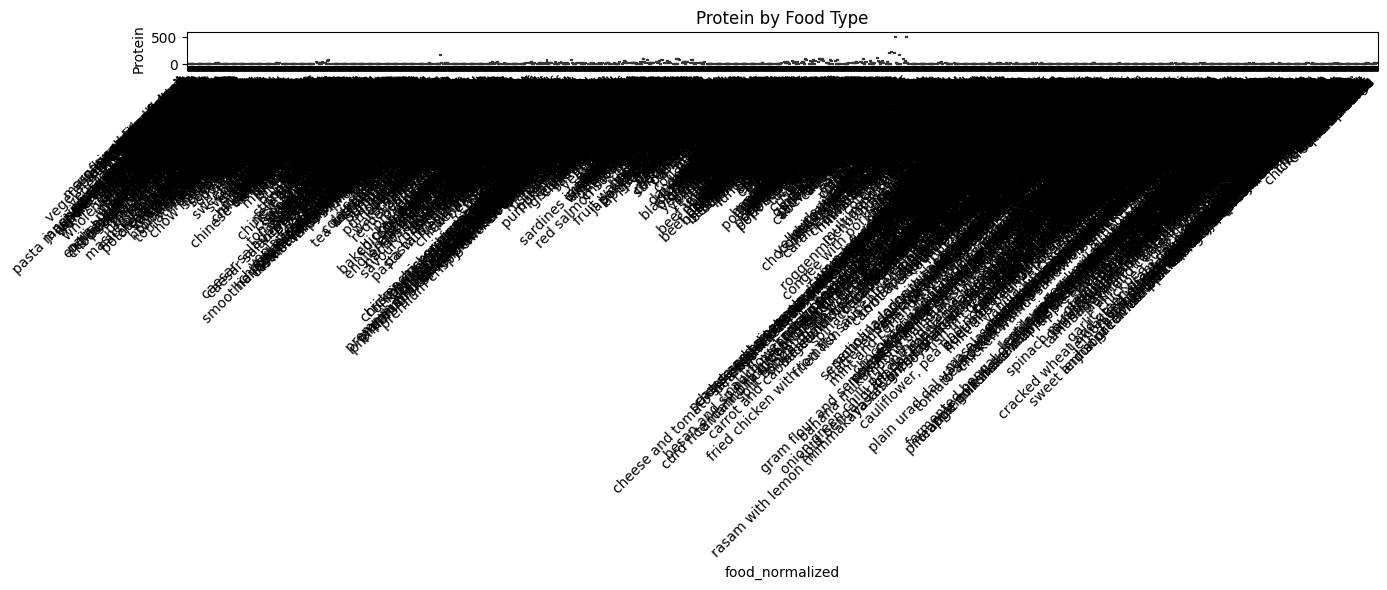

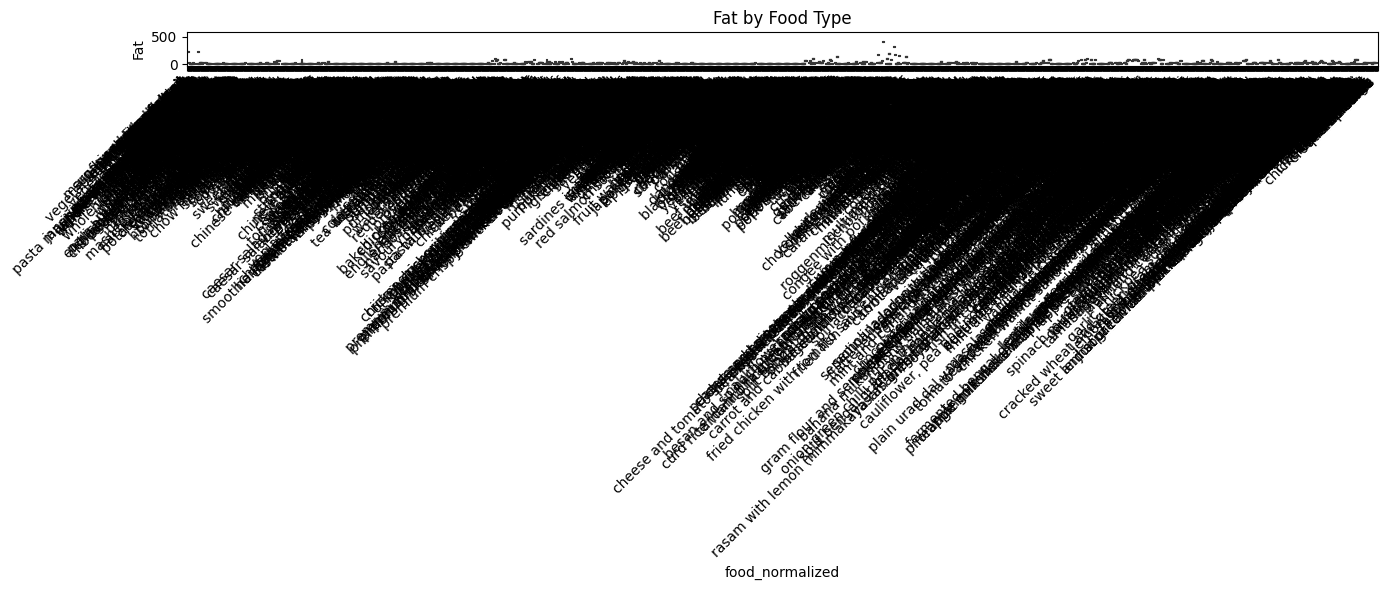

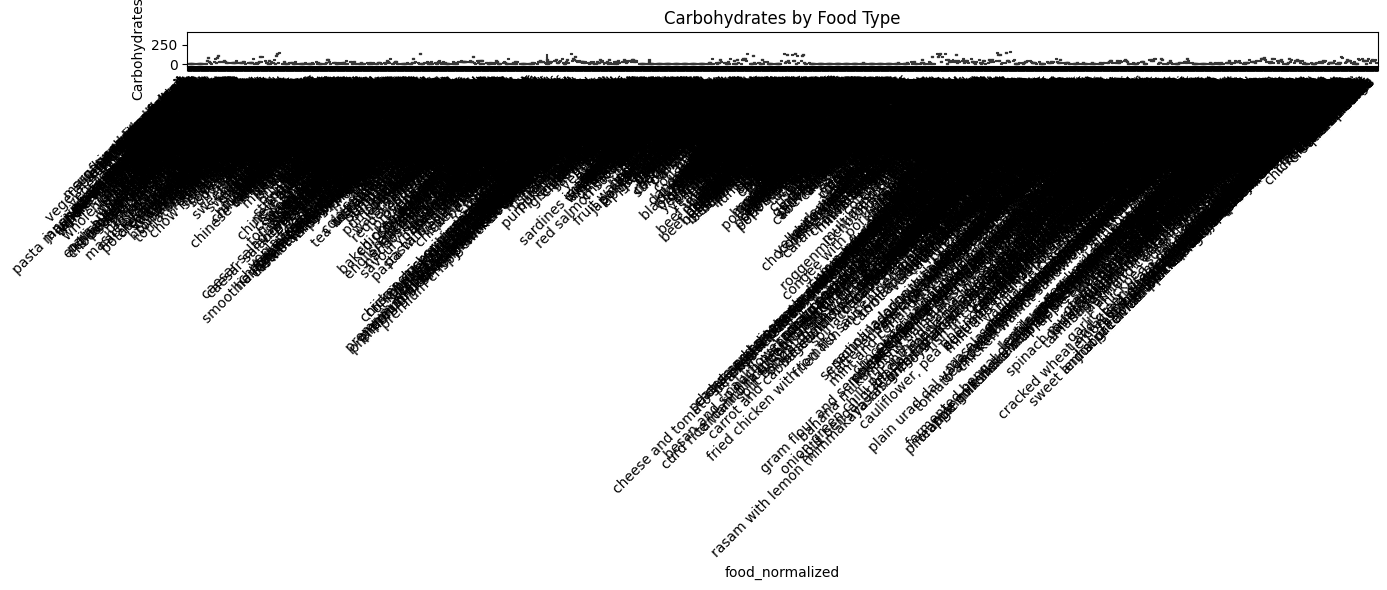

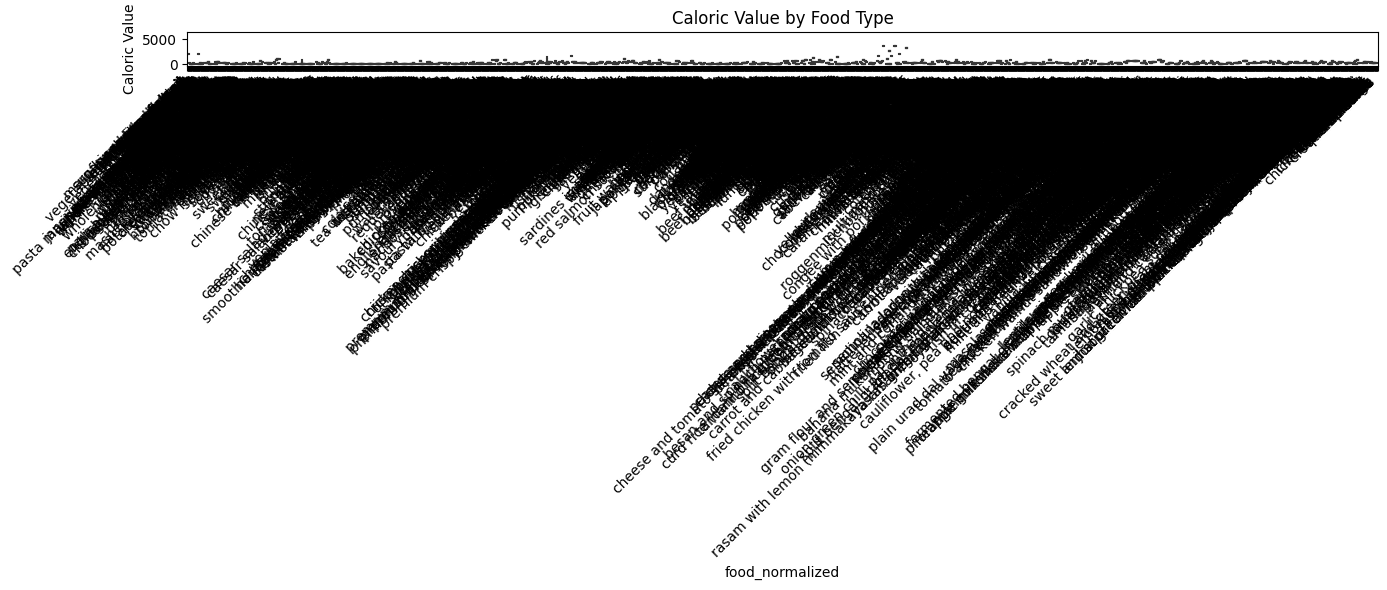

In [14]:
nutrients = ['Protein', 'Fat', 'Carbohydrates', 'Caloric Value']

for nutrient in nutrients:
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df, x='food_normalized', y=nutrient, palette='coolwarm')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'{nutrient} by Food Type')
    plt.tight_layout()
    plt.show()

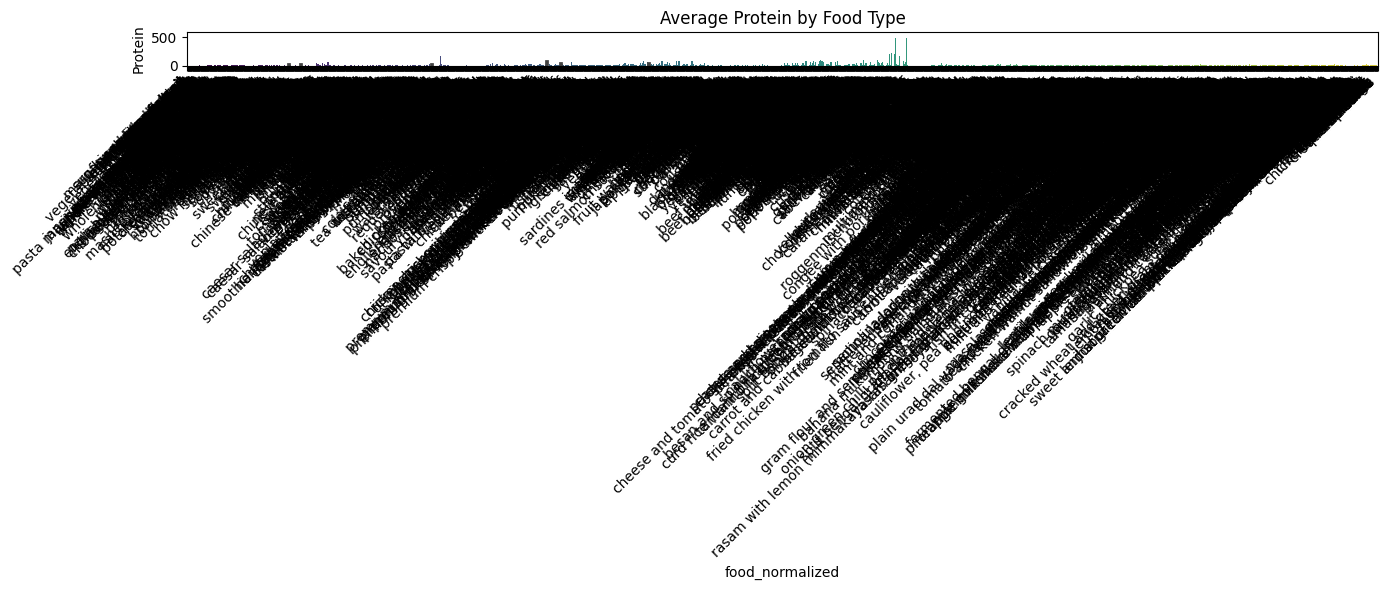

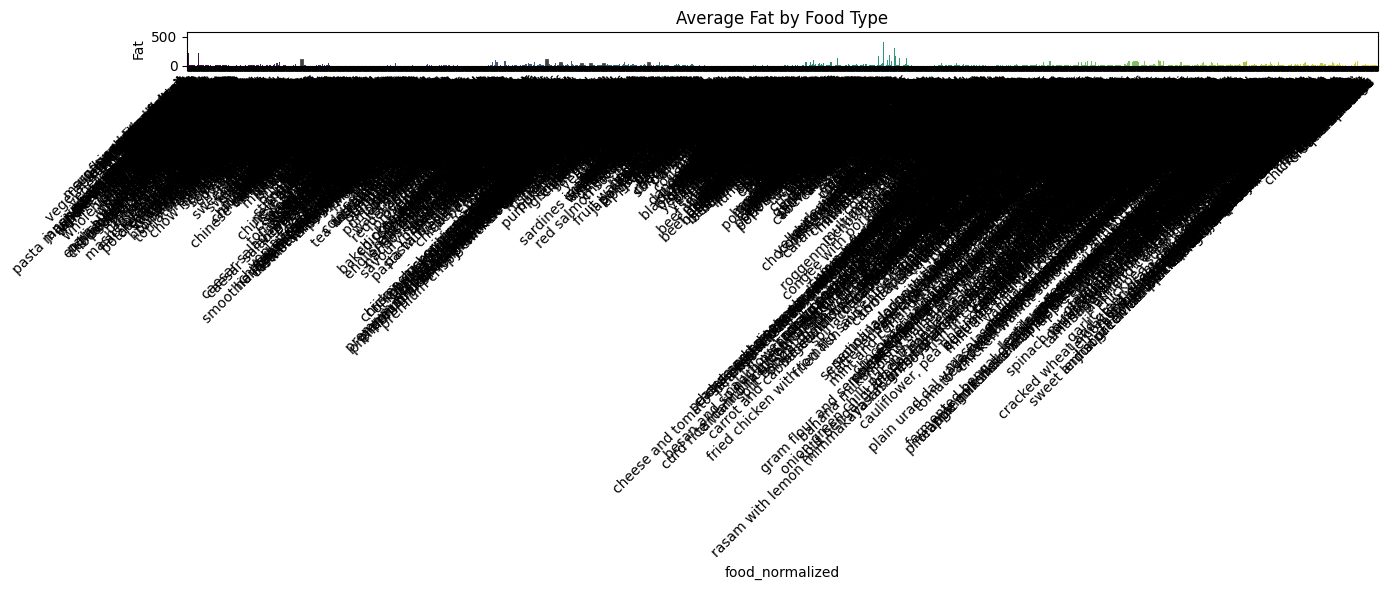

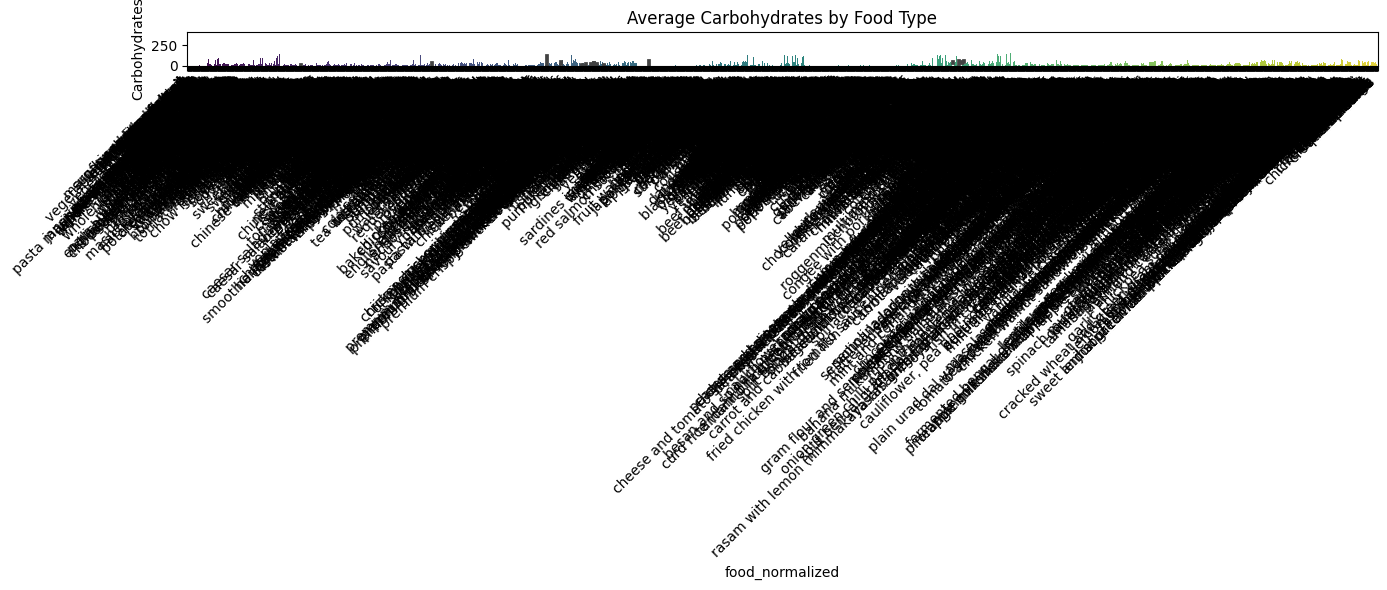

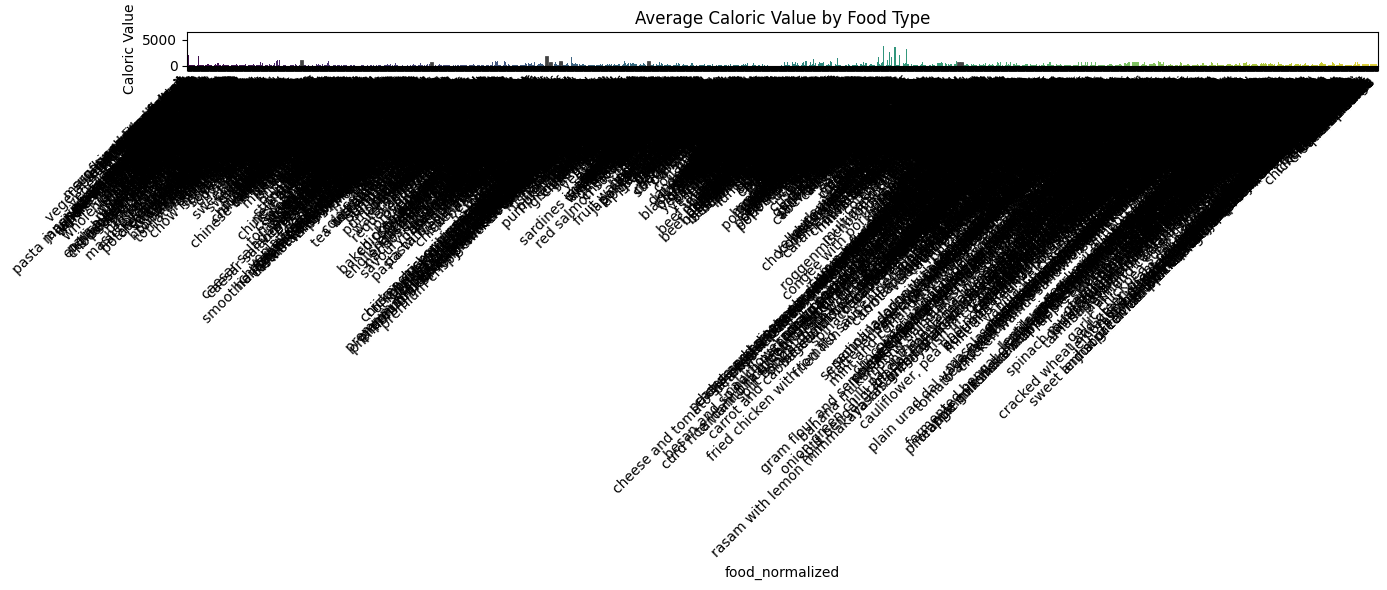

In [15]:
for nutrient in nutrients:
    plt.figure(figsize=(14, 6))
    sns.barplot(data=df, x='food_normalized', y=nutrient, palette='viridis', estimator='mean')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Average {nutrient} by Food Type')
    plt.tight_layout()
    plt.show()


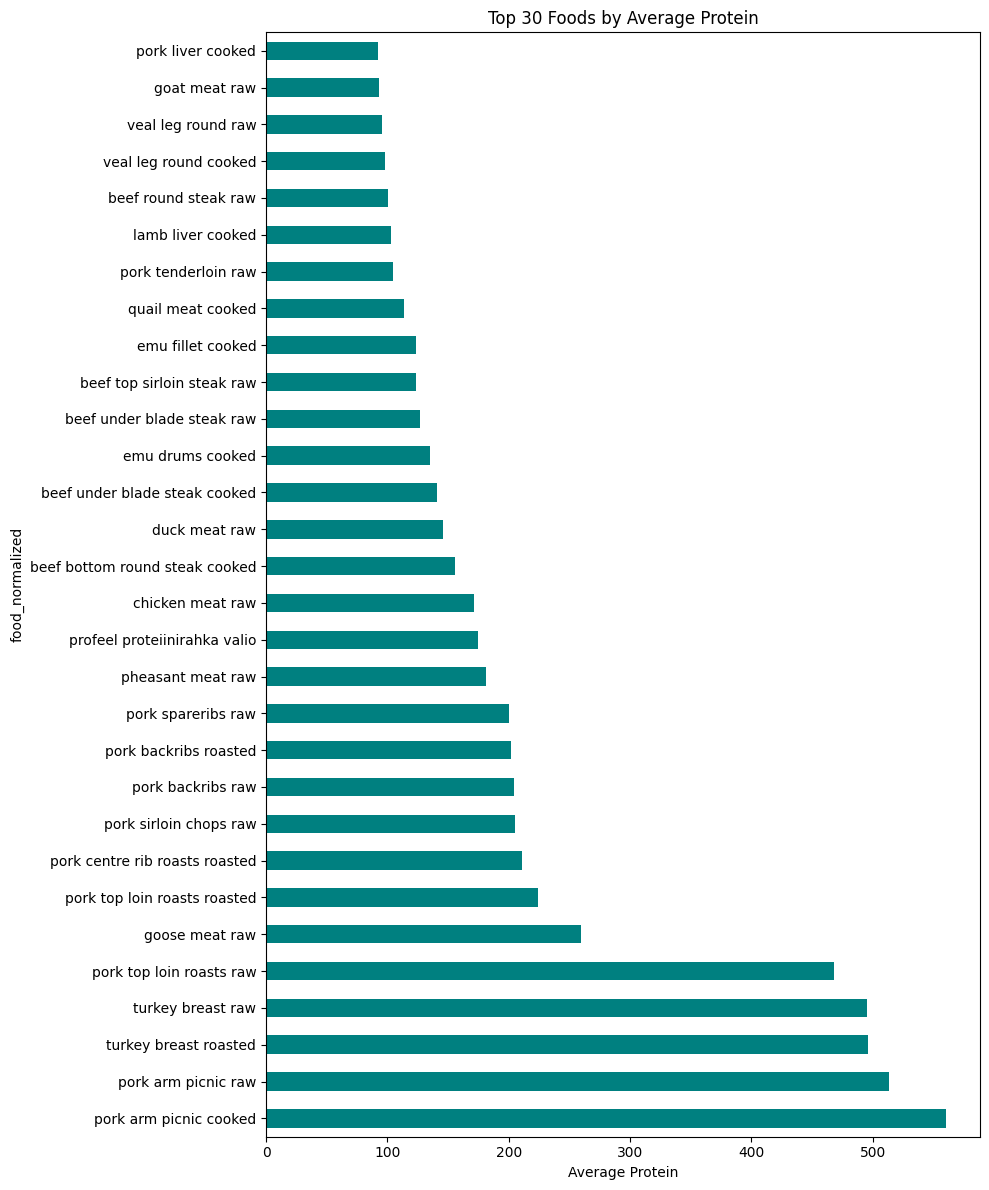

In [16]:
avg_protein = df.groupby('food_normalized')['Protein'].mean().sort_values(ascending=False).head(30)
avg_protein.plot(kind='barh', figsize=(10, 12), color='teal')
plt.xlabel("Average Protein")
plt.title("Top 30 Foods by Average Protein")
plt.tight_layout()
plt.show()


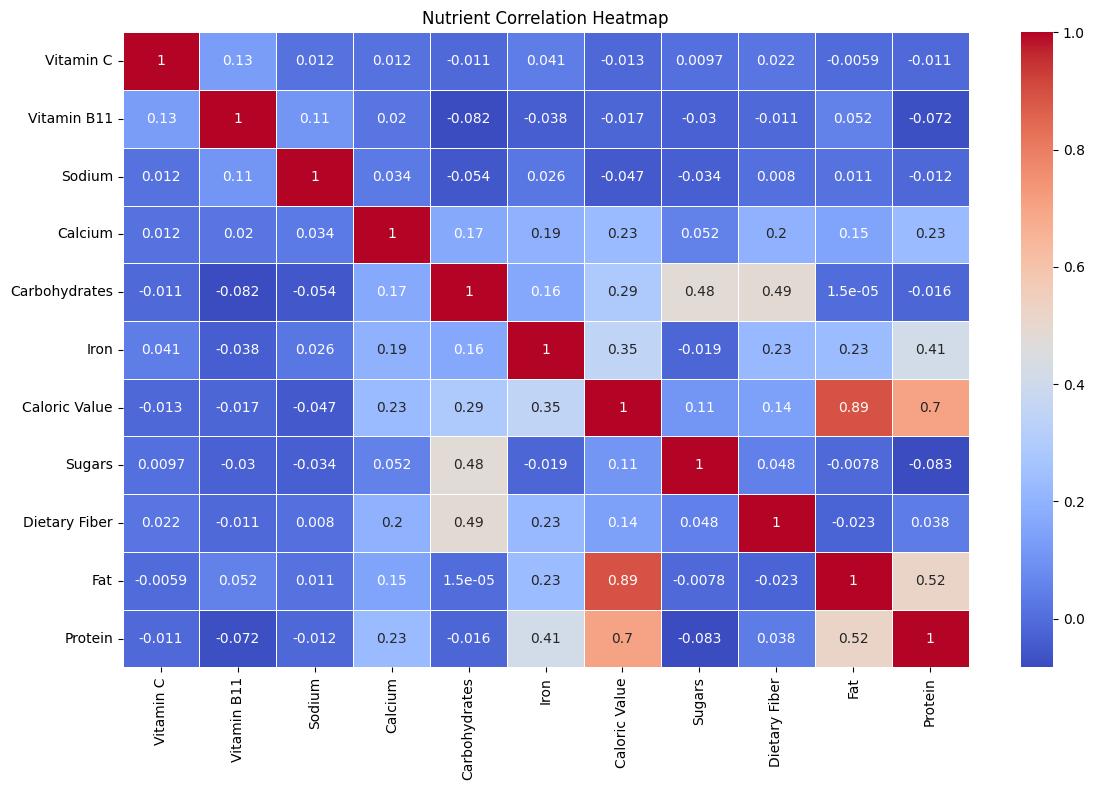

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Nutrient Correlation Heatmap')
plt.tight_layout()
plt.show()


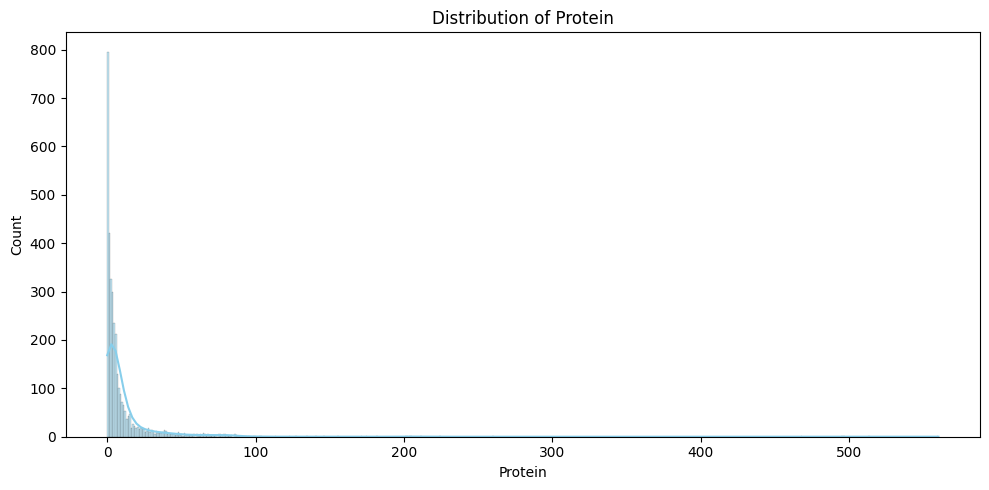

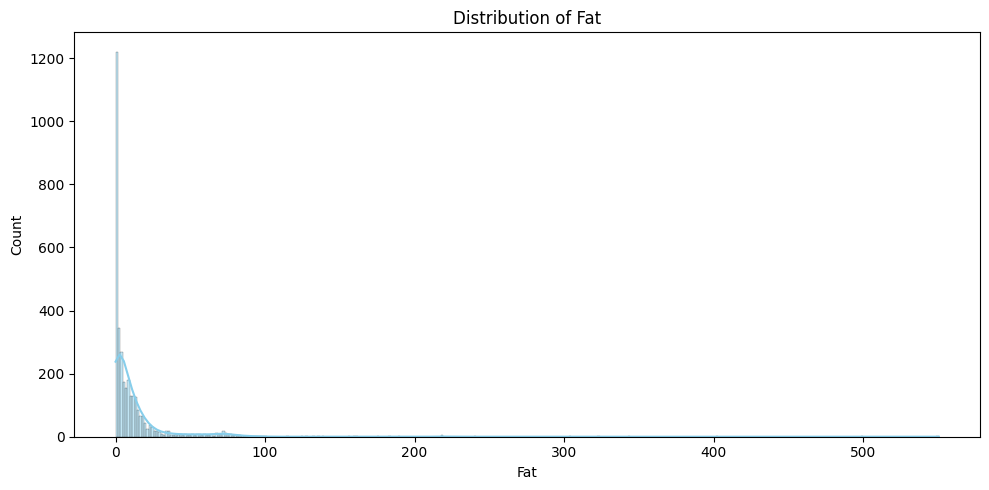

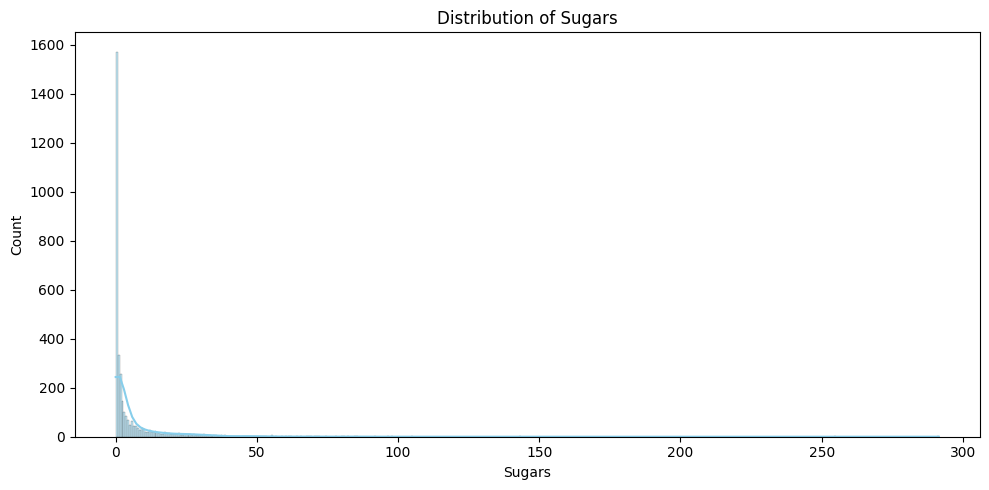

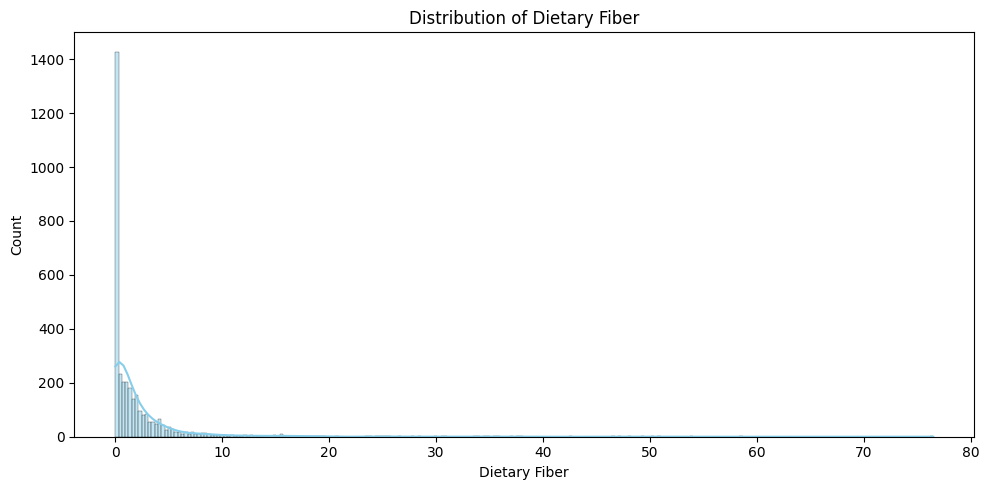

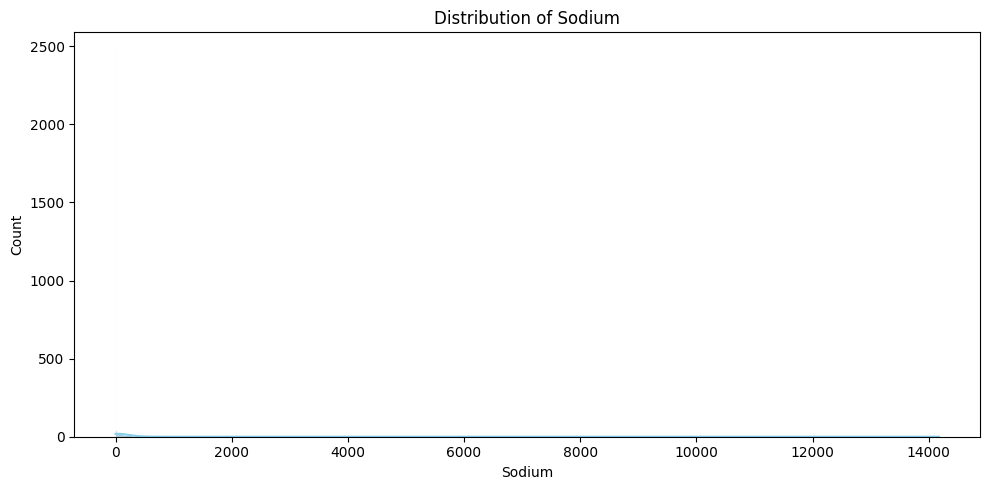

In [18]:
key_nutrients = ['Protein', 'Fat', 'Sugars', 'Dietary Fiber', 'Sodium']

for nutrient in key_nutrients:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[nutrient], kde=True, color='skyblue')
    plt.title(f'Distribution of {nutrient}')
    plt.tight_layout()
    plt.show()


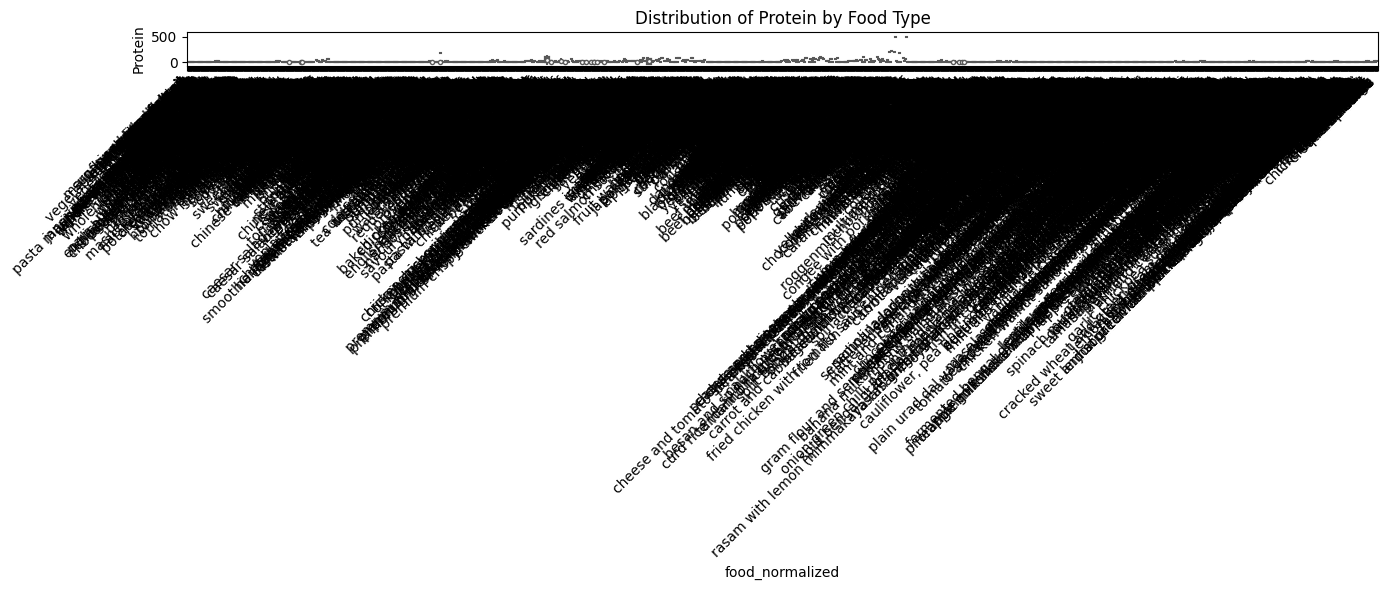

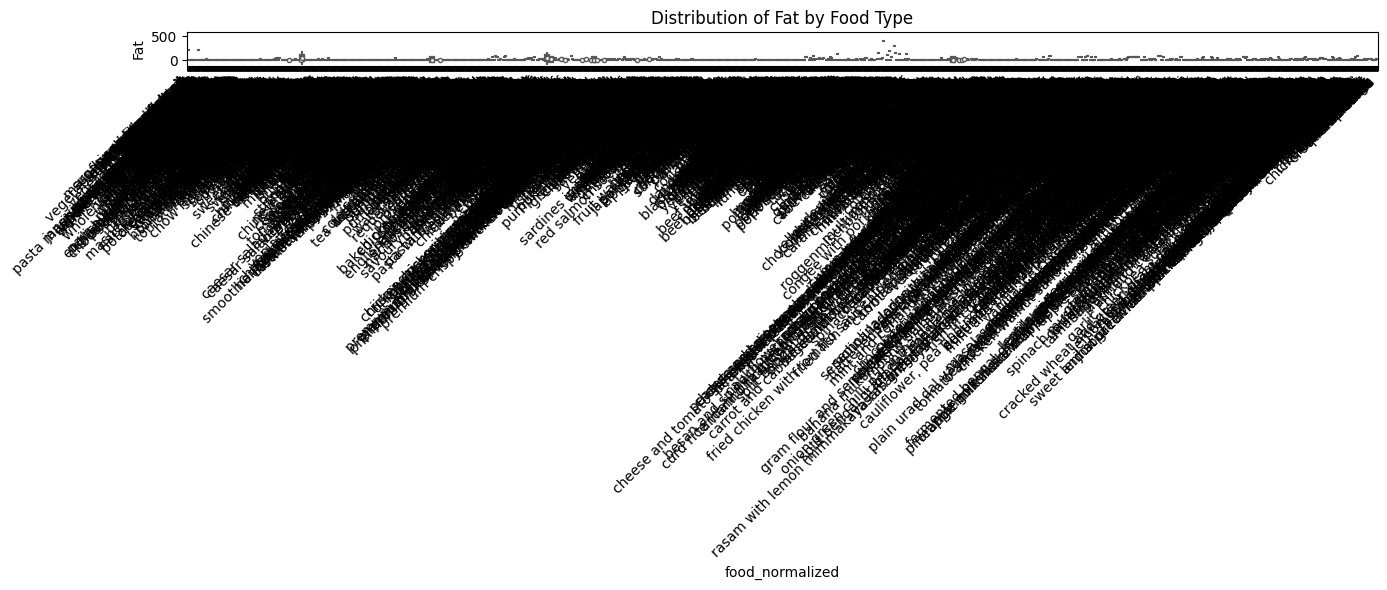

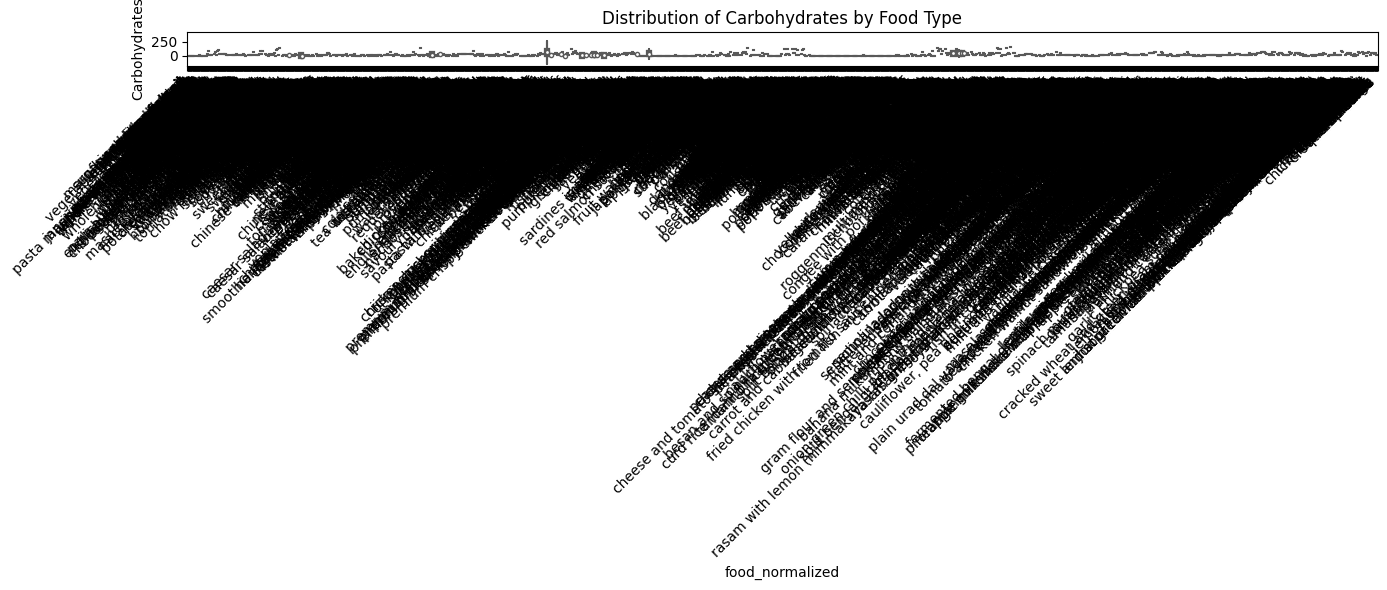

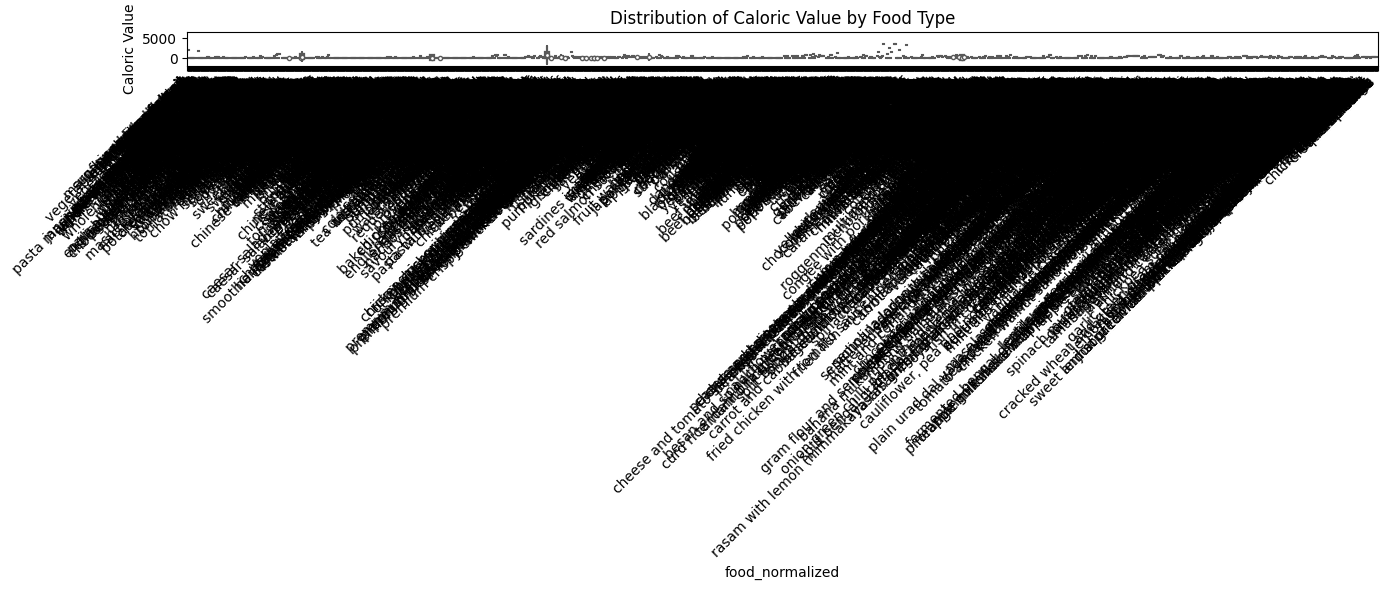

In [19]:
for nutrient in nutrients:
    plt.figure(figsize=(14, 6))
    sns.violinplot(data=df, x='food_normalized', y=nutrient, palette='Set2')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Distribution of {nutrient} by Food Type')
    plt.tight_layout()
    plt.show()


## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [21]:
# 2. Features and label
X = df.drop(['food', 'food_normalized'], axis=1)
y = df['food_normalized']

In [22]:
# 3. Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [23]:
# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [24]:
# 5. ML models to apply
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

In [25]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc
    print(f"🔍 {name} Accuracy: {acc:.2f}%")

print("\n🏆 Top 3 Models:")
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True)[:3]:
    print(f"{name:<20}: {acc:.2f}%")


🔍 Random Forest Accuracy: 0.00%
🔍 Decision Tree Accuracy: 0.00%
🔍 Logistic Regression Accuracy: 0.00%
🔍 SVM Accuracy: 0.00%
🔍 Naive Bayes Accuracy: 0.00%
🔍 KNN Accuracy: 0.00%

🏆 Top 3 Models:
Random Forest       : 0.00%
Decision Tree       : 0.00%
Logistic Regression : 0.00%


## Thank you...pls upvote!!!